# Reproducing the main-text figures from the Source Data

**NATCHEMENG-25051060 — *Genetic encoding and mutagenesis of RNA droplet phenotypes***

This notebook redraws every graph in the main text **using nothing but the Source Data
files submitted with the paper**. No microscopy, no segmentation output, no TrackMate XML,
no raw CSVs — just the `.xlsx` workbooks a reader can download.

That is the point: if a panel here matches the published figure, the Source Data is complete
and the figure is reproducible from it alone.

| Panel | Sheet used |
|---|---|
| **Fig. 1f** — droplet count ⟨N⟩ and vacuole/droplet area ratio vs time | `Source_Data_Fig1.xlsx` → `Fig1f_plotted` |
| **Fig. 2c** — vacuole/droplet area ratio per field of view | `Source_Data_Fig2.xlsx` → `Fig2c_plotted` |
| **Fig. 5b** — medusa plots of droplet trajectories | `Source_Data_Fig5.xlsx` → `Fig5b_plotted` |
| **Fig. 5c** — final mean squared displacement | `Source_Data_Fig5.xlsx` → `Fig5c_plotted` |
| **Fig. 5d** — polar distribution of the angle α | `Source_Data_Fig5.xlsx` → `Fig5d_plotted` |

**Figure 3 contains no graphs**, so it has no Source Data and appears nowhere here.

**Code for generating the graphs in figure 4 (theory, see the original publication) are in another script, belonging to Christoph Weber and Pranay Jaiswal.**

---

### How to use

1. Put this notebook in the same folder as the `Source_Data_Fig*.xlsx` files, or set
   `SOURCE_DIR` below.
2. Run all cells.
3. Each panel is drawn inline and written to `OUT_DIR` as SVG and PNG.

Nothing is written to the Source Data files themselves — they are opened read-only.

## 1. Setup

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

print("pandas", pd.__version__, "| seaborn", sns.__version__, "| matplotlib", mpl.__version__)

pandas 2.2.2 | seaborn 0.13.2 | matplotlib 3.9.1


In [6]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# Folder holding the Source_Data_Fig*.xlsx files ("." = same folder as this notebook)
SOURCE_DIR = '/Users/wverstra/Desktop/Source Data/Source_Data_Main/'

# Where the redrawn panels are written
OUT_DIR = "replots"

os.makedirs(OUT_DIR, exist_ok=True)
print("reading Source Data from :", os.path.abspath(SOURCE_DIR))
print("writing panels to        :", os.path.abspath(OUT_DIR))

reading Source Data from : /Users/wverstra/Desktop/Source Data/Source_Data_Main
writing panels to        : /Users/wverstra/Desktop/Files for submission/replots


### Plot style

Copied from the notebooks that produced the published figures, so a panel that looks
different here reflects a real difference in the data rather than a styling artefact.

In [7]:
RC = {
    "text.usetex": False,
    "svg.fonttype": "none",      # keeps text editable in the SVG
    "font.size": 7,
    "lines.linewidth": 0.5,
    "figure.figsize": (2, 2),
    "lines.markersize": 4,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "ytick.major.size": 5,
    "xtick.major.size": 5,
    "ytick.major.width": 1.1,
    "xtick.major.width": 1.1,
    "xtick.top": False,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "ytick.minor.width": 1.1,
    "xtick.minor.width": 1.1,
}

RED = "#e51818ff"

# Fig. 2c palette.
# NOTE: in the original notebook the palette is passed as a positional list while
# seaborn orders the categories alphabetically by internal condition name
# (M+L1 -> M+TOP -> Main band), i.e. M+S -> M+L -> M. The first colour therefore
# lands on M+S. The mapping below reproduces what the code actually draws.
FIG2C_COLOURS = {"M+S": "#84206bff", "M+L": "#e55c30ff", "M": "#f6d746ff"}

N_BINS_POLAR = 30                       # Fig. 5d, as in circular_plot.ipynb


def apply_style():
    mpl.rcParams.update(RC)
    sns.set_style({"xtick.direction": "in", "ytick.direction": "in"})
    sns.set_style({"ytick.right": True, "xtick.top": True})


apply_style()

### Helper fucntions for the plotting, note that plot layout might have been slightly modified in inkscape after this step

In [8]:
def load(workbook, sheet):
    """Read one sheet of a Source Data workbook, read-only."""
    path = os.path.join(SOURCE_DIR, workbook)
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"{path} not found — set SOURCE_DIR to the folder holding the "
            f"Source_Data_Fig*.xlsx files."
        )
    df = pd.read_excel(path, sheet_name=sheet)
    print(f"{workbook} :: {sheet}  ->  {len(df)} rows")
    return df


def save(fig, name):
    """Write the panel as SVG (vector, for figure assembly) and PNG (for a quick look)."""
    for ext in ("svg", "png"):
        p = os.path.join(OUT_DIR, f"{name}.{ext}")
        fig.savefig(p, format=ext, dpi=600, bbox_inches="tight")
    print(f"   saved {name}.svg / .png")


def readme(workbook):
    """Show a workbook's README sheet — what each sheet contains."""
    return load(workbook, "README")

In [9]:
# What is in each workbook
for wb in ["Source_Data_Fig1.xlsx", "Source_Data_Fig2.xlsx", "Source_Data_Fig5.xlsx"]:
    display(readme(wb))

Source_Data_Fig1.xlsx :: README  ->  2 rows


,sheet,panel,content,description,rows
0,Fig1f_plotted,Fig1f,points as plotted,Timelapse: droplet count per FOV and vacuole/d...,296
1,Fig1f_per_object,Fig1f,individual measurements,Timelapse: droplet count per FOV and vacuole/d...,205739


Source_Data_Fig2.xlsx :: README  ->  2 rows


,sheet,panel,content,description,rows
0,Fig2c_plotted,Fig2c,points as plotted,"Ratio of vacuole area to total droplet area, a...",43
1,Fig2c_per_object,Fig2c,individual measurements,"Ratio of vacuole area to total droplet area, a...",2589


Source_Data_Fig5.xlsx :: README  ->  3 rows


,sheet,panel,content,description,rows
0,Fig5b_plotted,Fig5b,points as plotted,Medusa plots: positions over time of the 50 mo...,14749
1,Fig5c_plotted,Fig5c,points as plotted,Final squared displacement of the 100 most mob...,200
2,Fig5c_per_object,Fig5c,individual measurements,Final squared displacement of the 100 most mob...,2213


## 2. Figure 1f — droplet count and vacuole area ratio over time

Two quantities share the time axis:

* **⟨N⟩** — droplets detected per field of view, averaged over fields of view (± s.e.m.
  across fields of view, `n_FOV`);
* **A(vacuole)/A(droplet)** — averaged over all droplets at that timepoint (± s.e.m. across
  droplets, `n_droplets`). Note that `n_droplets` is not a constant number over time and this no single distinct sample size can be used here

The two error bands are computed over **different units**, which is why both counts are
columns in the sheet rather than left to be inferred.

In [6]:
d = load("Source_Data_Fig1.xlsx", "Fig1f_plotted")
d.head()

Source_Data_Fig1.xlsx :: Fig1f_plotted  ->  296 rows


,label,condition,timepoint,mean_droplet_count,sem_droplet_count,n_FOV,mean_area_ratio,sem_area_ratio,n_droplets
0,Mut,DrWa PCR,0.000000,451.142857,169.825320,7,0.013809,0.000226,3158
1,Mut,DrWa PCR,0.333333,753.285714,62.380062,7,0.013826,0.000194,5273
2,Mut,DrWa PCR,0.666667,369.142857,48.276697,7,0.016156,0.000304,2584
3,Mut,DrWa PCR,1.000000,94.857143,10.495869,7,0.015805,0.000622,664
4,Mut,DrWa PCR,1.333333,60.285714,5.527913,7,0.013269,0.000947,422


   saved Fig1f.svg / .png


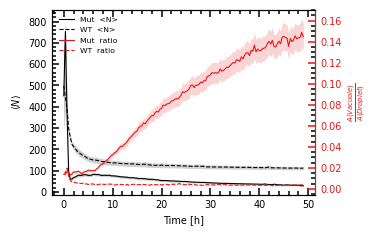

In [7]:
apply_style()
fig, ax_count = plt.subplots(figsize=(3.4, 2.4))
ax_ratio = ax_count.twinx()

for label, ls in [("Mut", "-"), ("WT", "--")]:
    s = d[d.label == label].sort_values("timepoint")

    ax_count.plot(s.timepoint, s.mean_droplet_count, ls, color="black",
                  linewidth=0.8, label=f"{label}  <N>")
    ax_count.fill_between(s.timepoint,
                          s.mean_droplet_count - s.sem_droplet_count,
                          s.mean_droplet_count + s.sem_droplet_count,
                          color="black", alpha=0.18, linewidth=0)

    ax_ratio.plot(s.timepoint, s.mean_area_ratio, ls, color=RED,
                  linewidth=0.8, label=f"{label}  ratio")
    ax_ratio.fill_between(s.timepoint,
                          s.mean_area_ratio - s.sem_area_ratio,
                          s.mean_area_ratio + s.sem_area_ratio,
                          color=RED, alpha=0.18, linewidth=0)

ax_count.set_xlabel("Time [h]")
ax_count.set_ylabel(r"$\langle N \rangle$")
ax_ratio.set_ylabel(r"$\frac{A(Vacuole)}{A(Droplet)}$", color=RED)
ax_ratio.tick_params(axis="y", colors=RED)
ax_ratio.spines["right"].set_color(RED)

h = ax_count.get_lines() + ax_ratio.get_lines()
ax_count.legend(h, [x.get_label() for x in h], fontsize=5.5, frameon=False,
                loc="upper left")

save(fig, "Fig1f")
plt.show()

## 3. Figure 2c — vacuole/droplet area ratio per field of view

One plotted point per field of view: the mean ratio over all droplets in that image.
Categories are drawn M+S (top) → M+L → M, as in the published panel.

In [8]:
d = load("Source_Data_Fig2.xlsx", "Fig2c_plotted")
print("\nn per condition:")
print(d.groupby("label").size().to_string())
d.head()

Source_Data_Fig2.xlsx :: Fig2c_plotted  ->  43 rows

n per condition:
label
M      18
M+L    15
M+S    10


,label,condition,image_ID,mean_vacuole_over_droplet_area
0,M+S,M+L1,Snap-10625.czi,0.089616
1,M+S,M+L1,Snap-10626.czi,0.052736
2,M+S,M+L1,Snap-10627.czi,0.026224
3,M+S,M+L1,Snap-10628.czi,0.067017
4,M+S,M+L1,Snap-10629.czi,0.040727


   saved Fig2c.svg / .png


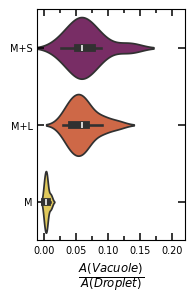

In [9]:
apply_style()
mpl.rcParams["ytick.minor.visible"] = False
mpl.rcParams["xtick.minor.visible"] = True

order = ["M+S", "M+L", "M"]

fig, ax = plt.subplots(figsize=(1.9, 3.0))
sns.violinplot(data=d, y="label", x="mean_vacuole_over_droplet_area",
               order=order, density_norm="width",
               palette=[FIG2C_COLOURS[k] for k in order],
               hue="label", hue_order=order, legend=False, alpha=1, ax=ax)

ax.xaxis.set_minor_locator(plt.MultipleLocator(0.025))
ax.set_ylabel(None)
ax.set_xlabel(r"$\frac{A(Vacuole)}{A(Droplet)}$", fontsize=12)
ax.set_xlim([-0.01, 0.22])

save(fig, "Fig2c")
plt.show()

## 4. Figure 5b — medusa plots

Each trajectory is shifted so it starts at the origin; the sheet carries both the raw
coordinates (`x_um`, `y_um`) and the shifted ones, so the panel can be redrawn without
knowing that the shift was applied.

⚠️ Trajectories are grouped by **`trajectory_uid`**, not `track_id`. TrackMate restarts
`track_id` at 0 in every file, so grouping on it would merge unrelated trajectories and
undercount.

In [36]:
d = load("Source_Data_Fig5.xlsx", "Fig5b_plotted")
print("\ntrajectories drawn per condition:")
print(d.groupby("label")["trajectory_uid"].nunique().to_string())

Source_Data_Fig5.xlsx :: Fig5b_plotted  ->  14749 rows

trajectories drawn per condition:
label
Mut    50
WT     50


   saved Fig5b_WT.svg / .png


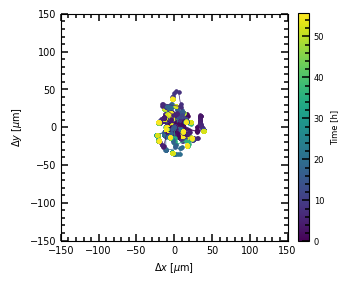

   saved Fig5b_Mut.svg / .png


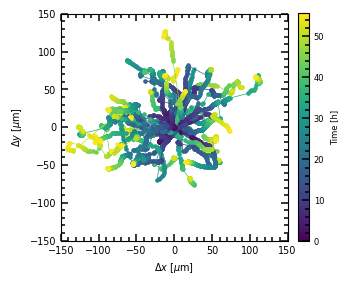

In [37]:
apply_style()
cmap = plt.get_cmap("viridis")

for label in ["WT", "Mut"]:
    s = d[d.label == label]
    norm = plt.Normalize(vmin=s.time_s.min(), vmax=s.time_s.max())

    fig, ax = plt.subplots(figsize=(3.2, 3.2))
    for _, g in s.groupby("trajectory_uid"):
        g = g.sort_values("time_s")
        xs, ys, ts = g.x_shifted_um.values, g.y_shifted_um.values, g.time_s.values
        for i in range(len(xs) - 1):
            ax.plot(xs[i:i + 2], ys[i:i + 2], marker="o", linestyle="-",
                    linewidth=0.5, markersize=2, color=cmap(norm(ts[i])))

    ax.set_aspect("equal")
    ax.set_xlabel(r"$\Delta x$ [$\mu$m]")
    ax.set_ylabel(r"$\Delta y$ [$\mu$m]")
    ax.set_xlim([-150, 150])
    ax.set_ylim([-150, 150])

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(
        vmin=s.time_h.min(), vmax=s.time_h.max()))
    cb = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("Time [h]", fontsize=6)
    cb.ax.tick_params(labelsize=6)

    save(fig, f"Fig5b_{label}")
    plt.show()

## 5. Figure 5c — final mean squared displacement

The plotted value is `final_sd_1e3_um2` (µm² / 1000), matching the published axis label;
`final_sd_um2` in the same sheet holds the unscaled value.

The `Fig5c_per_object` sheet lists **every** tracked trajectory with a `used_in_figure`
flag, so the selection of the most mobile ones is auditable.

In [38]:
d = load("Source_Data_Fig5.xlsx", "Fig5c_plotted")
o = load("Source_Data_Fig5.xlsx", "Fig5c_per_object")
print("\nplotted per condition:")
print(d.groupby("label").size().to_string())
print("\ntotal trajectories tracked (the n quoted in the caption):")
print(o.groupby("label").size().to_string())

Source_Data_Fig5.xlsx :: Fig5c_plotted  ->  200 rows
Source_Data_Fig5.xlsx :: Fig5c_per_object  ->  2213 rows

plotted per condition:
label
Mut    100
WT     100

total trajectories tracked (the n quoted in the caption):
label
Mut     724
WT     1489


   saved Fig5c.svg / .png


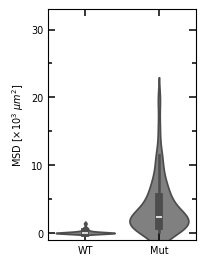

In [13]:
apply_style()
mpl.rcParams["ytick.minor.visible"] = True
mpl.rcParams["xtick.minor.visible"] = False

fig, ax = plt.subplots(figsize=(1.9, 3.0))
sns.violinplot(data=d, x="label", y="final_sd_1e3_um2",
               order=["WT", "Mut"], density_norm="width", color="gray", ax=ax)
ax.yaxis.set_minor_locator(plt.MultipleLocator(5))
ax.set_xlabel(None)
ax.set_ylabel(r"MSD [$\times 10^{3}\ \mu m^{2}$]", fontsize=7)
ax.set_ylim([-1, 33])
ax.locator_params(axis="y", nbins=4)

save(fig, "Fig5c")
plt.show()

## 6. Figure 5d — polar distribution of the angle α

α is the angle between the droplet's displacement and the displacement of the vacuole
centre relative to the droplet centre. The sheet stores it as `alpha_rad` / `alpha_deg`,
alongside the vector components it was computed from.

**Only timepoints at which the droplet centre moved more than 1 µm between frames appear
in this sheet (see methods section in the SI of the paper)** — below that the direction of motion is dominated by segmentation noise.
`delta_roi_length` is retained so the threshold can be inspected or re-applied. The
`Fig5d_per_object` sheet keeps the excluded rows with the reason recorded.

Bars are **percentages of the total**, 30 bins across 0–180°, zero at west, clockwise.

In [14]:
d = load("Source_Data_Fig5.xlsx", "Fig5d_plotted")
print(f"\n{len(d)} angles from {d.field_of_view.nunique()} fields of view "
      f"across {d.replicate.nunique()} replicates")
print("fields per replicate:")
print(d.groupby("replicate")["field_of_view"].nunique().to_string())
print(f"\nminimum droplet displacement present: {d.delta_roi_length.min():.3f} um "
      f"(the 1 um filter)")
print(f"angles greater than 90 degrees: {(d.alpha_deg > 90).mean() * 100:.2f} %")

Source_Data_Fig5.xlsx :: Fig5d_plotted  ->  2459 rows

2459 angles from 7 fields of view across 2 replicates
fields per replicate:
replicate
rep1    3
rep2    4

minimum droplet displacement present: 1.000 um (the 1 um filter)
angles greater than 90 degrees: 65.56 %


   saved Fig5d.svg / .png


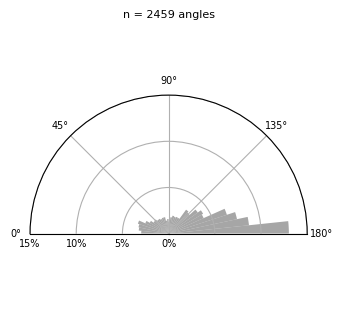

In [15]:
def polar_panel(ax, angles_rad, title):
    """Half-circular histogram, bar heights as per cent of the total."""
    ax.set_theta_zero_location("W")
    ax.set_theta_direction(-1)
    ax.set_thetamin(0)
    ax.set_thetamax(180)

    counts, bins = np.histogram(angles_rad, bins=N_BINS_POLAR, range=(0, np.pi))
    percent = counts / counts.sum() * 100
    centres = (bins[:-1] + bins[1:]) / 2

    ax.bar(centres, percent, width=np.diff(bins), color="gray", alpha=0.7)
    ax.set_xticks(np.linspace(0, np.pi, 5))
    ax.set_xticklabels([f"{int(np.degrees(t))}°"
                        for t in np.linspace(0, np.pi, 5)])
    ax.set_yticks(np.linspace(0, 15, 4))
    ax.set_yticklabels([f"{int(y)}%" for y in np.linspace(0, 15, 4)], fontsize=8)
    ax.grid(True)
    ax.set_title(title, fontsize=8)


apply_style()
mpl.rcParams["xtick.minor.visible"] = False
mpl.rcParams["ytick.minor.visible"] = False

fig = plt.figure(figsize=(3.6, 3.6))
ax = fig.add_subplot(111, projection="polar")
polar_panel(ax, d.alpha_rad.values, f"n = {len(d)} angles")
save(fig, "Fig5d")
plt.show()

## 8. What was written

Every panel above was drawn from a Source Data sheet and nothing else. If each matches its
published counterpart, the submitted Source Data is sufficient to reproduce the figures.

In [10]:
print("Files in", os.path.abspath(OUT_DIR), ":\n")
for f in sorted(os.listdir(OUT_DIR)):
    print(f"   {f:<40} {os.path.getsize(os.path.join(OUT_DIR, f)) / 1e3:>9.1f} kB")

Files in /Users/wverstra/Desktop/Files for submission/replots :

